# MohammadReza Safarpour **404464116**
# **EXERCISE 2 — SENTIMENT CLASSIFICATION ON YELP** **REVIEWS**



# 1. Setup & **Imports**

In [25]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import io
import os
import numpy as np

sns.set_style("whitegrid")


# **2. Download & Extract Yelp Dataset**

In [2]:
url = "https://business.yelp.com/external-assets/files/Yelp-JSON.zip"
filename = "Yelp-JSON.zip"

headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, stream=True, headers=headers)
response.raise_for_status()

with open(filename, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

!unzip Yelp-JSON.zip
!tar -xf "Yelp JSON/yelp_dataset.tar" -C .


Archive:  Yelp-JSON.zip
   creating: Yelp JSON/
  inflating: Yelp JSON/Yelp Dataset Documentation & ToS copy.pdf  
  inflating: __MACOSX/Yelp JSON/._Yelp Dataset Documentation & ToS copy.pdf  
  inflating: Yelp JSON/yelp_dataset.tar  
  inflating: __MACOSX/Yelp JSON/._yelp_dataset.tar  


# **3. Load & Sample Data**

In [3]:
business_file = 'yelp_academic_dataset_business.json'
review_file = 'yelp_academic_dataset_review.json'
user_file = 'yelp_academic_dataset_user.json'

# Sampling rates
sample_rate_business = 0.50
sample_rate_large = 0.10

# Business
sampled_business_lines = []
with open(business_file, 'r', encoding='utf-8') as f:
    for line in f:
        if random.random() < sample_rate_business:
            sampled_business_lines.append(line)
df_business_sampled = pd.read_json(io.StringIO(''.join(sampled_business_lines)), lines=True)

# Review
sampled_review_lines = []
with open(review_file, 'r', encoding='utf-8') as f:
    for line in f:
        if random.random() < sample_rate_large:
            sampled_review_lines.append(line)
df_review_sampled = pd.read_json(io.StringIO(''.join(sampled_review_lines)), lines=True)

# User
sampled_user_lines = []
with open(user_file, 'r', encoding='utf-8') as f:
    for line in f:
        if random.random() < sample_rate_large:
            sampled_user_lines.append(line)
df_user_sampled = pd.read_json(io.StringIO(''.join(sampled_user_lines)), lines=True)

# Final DataFrames for assignment
df_business = df_business_sampled
df_review = df_review_sampled
df_user = df_user_sampled


In [4]:
# Robust setup: run this once before scenarios


sns.set_style("whitegrid")

# If df_business/df_review/df_user already exist, keep them;
# otherwise raise a clear error.
required = ['df_business', 'df_review', 'df_user']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing DataFrames: {missing}. Please run the data loading cells first.")

# Coerce types safely used by plots
if 'date' in df_review.columns:
    df_review = df_review.copy()
    df_review['review_date'] = pd.to_datetime(df_review['date'], errors='coerce')


# **Setup & Imports**

In [13]:
# ============================================================
# EXERCISE 2 (ML Version) — SENTIMENT CLASSIFICATION ON YELP
# SpecialTopic_HM02
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import random
import re

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

print("ML Exercise 2 environment ready.")


ML Exercise 2 environment ready.


# **Prepare Sentiment Labels**

In [14]:
# Create dataframe for sentiment analysis
df_sent = df_review[['text', 'stars']].dropna().copy()

# Apply labeling rule
df_sent['sentiment'] = df_sent['stars'].apply(lambda s: 1 if s >= 3 else 0)

print("Label distribution:")
print(df_sent['sentiment'].value_counts())

df_sent.head()


Label distribution:
sentiment
1    537277
0    161190
Name: count, dtype: int64


,text,stars,sentiment
0,"Upland is a brewery based out of Bloomington, ...",3,1
1,I thoroughly enjoyed the show. Chill way to s...,5,1
2,"Comfortable bed, good breakfast, fast internet...",4,1
3,NEVER AGAIN. This is a so called restaurant th...,2,0
4,If you want to pay for everything a la carte t...,1,0


# Train/Test Split (80/20)**bold text**

In [15]:
X = df_sent['text']
y = df_sent['sentiment']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 558773
Test size: 139694


# TF-IDF **Vectorization**

In [16]:
# TF-IDF features
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("TF-IDF feature matrix created.")
print("Shape:", X_train_vec.shape)


TF-IDF feature matrix created.
Shape: (558773, 50000)


# **Train Logistic Regression Model**

In [17]:
model = LogisticRegression(
    max_iter=400,
    class_weight='balanced',    # helps with negative class
    n_jobs=-1
)

model.fit(X_train_vec, y_train)

print("Model trained successfully.")


Model trained successfully.


# **Model Predictions**

In [18]:
y_pred = model.predict(X_test_vec)

print("Predictions completed.")


Predictions completed.


# Confusion Matrix **Visualization**

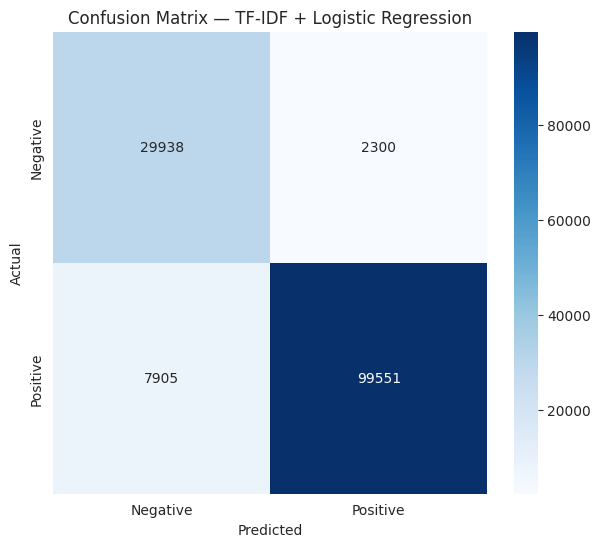

TN, FP, FN, TP: 29938 2300 7905 99551


In [19]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.title("Confusion Matrix — TF-IDF + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("TN, FP, FN, TP:", tn, fp, fn, tp)


# Evaluation **Metrics**

In [20]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("="*70)
print("TF-IDF + Logistic Regression — Evaluation Metrics")
print("="*70)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.1f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.1f}%)")
print(f"F1 Score:  {f1:.4f} ({f1*100:.1f}%)")


TF-IDF + Logistic Regression — Evaluation Metrics
Accuracy:  0.9269 (92.7%)
Precision: 0.9774 (97.7%)
Recall:    0.9264 (92.6%)
F1 Score:  0.9512 (95.1%)


# Classification **Report**

In [21]:
print("="*70)
print("Classification Report — ML Model")
print("="*70)
print(classification_report(
    y_test, y_pred,
    target_names=["Negative", "Positive"],
    digits=4
))


Classification Report — ML Model
              precision    recall  f1-score   support

    Negative     0.7911    0.9287    0.8544     32238
    Positive     0.9774    0.9264    0.9512    107456

    accuracy                         0.9269    139694
   macro avg     0.8843    0.9275    0.9028    139694
weighted avg     0.9344    0.9269    0.9289    139694



# Metrics Bar **Chart**

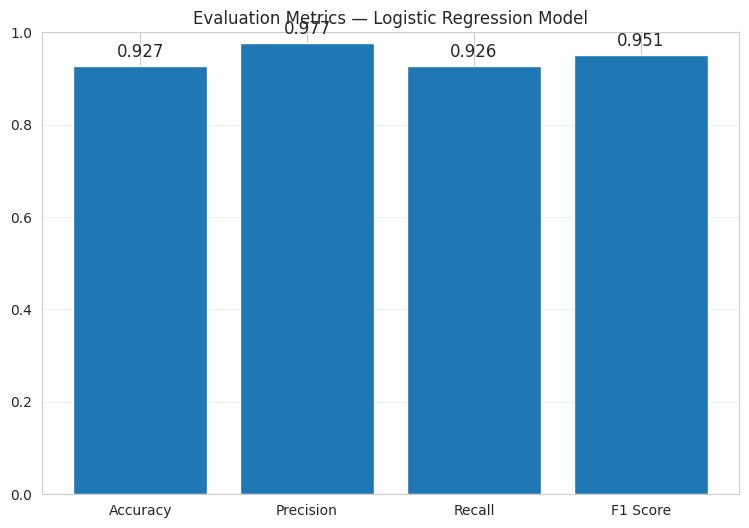

In [22]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metrics_values = [accuracy, precision, recall, f1]

plt.figure(figsize=(9, 6))
bars = plt.bar(metrics_names, metrics_values)

plt.ylim(0, 1)
plt.title("Evaluation Metrics — Logistic Regression Model")

for bar, val in zip(bars, metrics_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{val:.3f}",
        ha='center',
        fontsize=12
    )

plt.grid(axis='y', alpha=0.3)
plt.show()


# Final **Summary**

In [24]:
print("="*70)
print("SUMMARY — TF-IDF + Logistic Regression")
print("="*70)
print(f"Correct Predictions:   {tn + tp}")
print(f"Incorrect Predictions: {fp + fn}")
print(f"Accuracy: {accuracy*100:.1f}%")
print(f"Precision: {precision*100:.1f}%")
print(f"Recall:    {recall*100:.1f}%")
print(f"F1 Score:  {f1*100:.1f}%")




SUMMARY — TF-IDF + Logistic Regression
Correct Predictions:   129489
Incorrect Predictions: 10205
Accuracy: 92.7%
Precision: 97.7%
Recall:    92.6%
F1 Score:  95.1%
